In [33]:
! pip install opencxr

### Muntatge de Google Drive
Muntatge de Google Drive per accedir als fitxers del projecte.


In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Definició de rutes del dataset
Definició de les rutes cap a les imatges i el fitxer de metadades utilitzat en l’experiment.


In [58]:
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"

PATH_IMAGES = f"{BASE_PATH}/images"
PATH_METADATA = f"{BASE_PATH}/metadata_augmented.csv"
PATH_METADATA = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata_augmented_def2.csv"
#PATH_METADATA = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata.csv"

print(PATH_IMAGES)
print(PATH_METADATA)

/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata_augmented_def2.csv


### Càrrega i distribució de classes
Càrrega de les metadades, construcció de les rutes de les imatges i càlcul del nombre de mostres negatives i positives.


In [59]:
import pandas as pd
import os

df = pd.read_csv(PATH_METADATA)

df["file_path"] = df["img_name"].apply(
    lambda x: f"{PATH_IMAGES}/{x.replace('.mha', '.png')}"
)

df.head()
num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()
print("Negativos:", num_neg)
print("Positivos:", num_pos)

Negativos: 3748
Positivos: 4427


### Verificació del dataset
Comprovació de l’existència dels fitxers PNG, inspecció inicial de les dades i anàlisi de la distribució de classes.


In [60]:
import pandas as pd
import os

# Cargar metadata
df = pd.read_csv(PATH_METADATA)

# Crear nueva ruta hacia PNG
df["file_path"] = df["img_name"].apply(
    lambda x: f"{PATH_IMAGES}/{x.replace('.mha', '.png')}"
)

# Mostrar primeras filas con información relevante
print(df[["img_name", "file_path"]].head())

# Verificar si las rutas son válidas
print("\nVerificando existencia de archivos PNG:")

for i in range(5):  # probar las 5 primeras rutas
    fp = df.loc[i, "file_path"]
    exists = os.path.exists(fp)
    print(f"{fp} → {'OK' if exists else 'NO ENCONTRADO'}")

# Contar positivos y negativos
num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()

print("\nResumen:")
print("Negativos:", num_neg)
print("Positivos:", num_pos)


    img_name                                          file_path
0  n0239.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
1  n0342.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
2  n0996.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
3  n0418.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
4  n0538.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...

Verificando existencia de archivos PNG:
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0239.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0342.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0996.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0418.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0538.png → OK

Resumen:
Negativos: 3748
Positivos: 4427


### Visualització d’anotacions
Mostra una imatge del dataset amb les bounding boxes dels nòduls superposades per verificar visualment les anotacions.


Mostrando: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0342.png


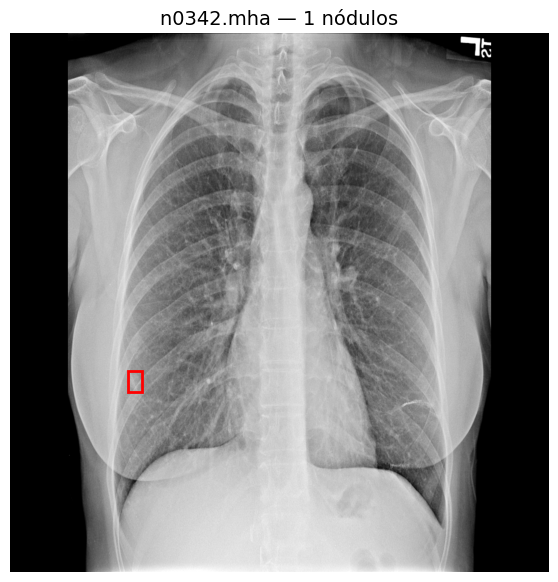

In [61]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np

def show_png_with_boxes(df, idx):
    # Obtener ruta y nombre del archivo
    path = df.loc[idx, "file_path"]
    img_name = df.loc[idx, "img_name"]
    print("Mostrando:", path)

    # Cargar imagen PNG
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("ERROR: No se pudo cargar la imagen")
        return

    # Normalización para visualización
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # Obtener todas las anotaciones de esta imagen
    rows = df[df["file_path"] == path]

    boxes = []
    for _, r in rows.iterrows():
        if r["label"] == 1:
            x1 = float(r["x"])
            y1 = float(r["y"])
            x2 = x1 + float(r["width"])
            y2 = y1 + float(r["height"])
            boxes.append((x1, y1, x2, y2))

    # ------------------------------
    #  VISUALIZACIÓN
    # ------------------------------
    fig, ax = plt.subplots(figsize=(7,7))
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{img_name} — {len(boxes)} nódulos", fontsize=14)

    # Dibujar cada bounding box
    for (x1, y1, x2, y2) in boxes:
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

    plt.axis("off")
    plt.show()
show_png_with_boxes(df, 1)

### Dataset NODE21 
Definició d’un `Dataset` de PyTorch que carrega imatges PNG, les normalitza a 3 canals i construeix les anotacions de detecció, mantenint un índex fix del DataFrame per garantir consistència en l’accés a les mostres.


In [62]:
import os
import torch
from torch.utils.data import Dataset
import numpy as np
import cv2

class Node21DetectionDatasetPNG(Dataset):
    def __init__(self, df):
        # Hacemos una copia para no modificar el df original
        self.df = df.copy()

        # Filtro: solo filas con la ruta válida
        self.df = self.df[self.df["file_path"].apply(os.path.exists)]

        # Lista de indices del df, en su orden natural (MUY IMPORTANTE)
        self.indices = self.df.index.tolist()


    def __len__(self):
        return len(self.indices)


    def __getitem__(self, idx):
        # Obtener el índice REAL en el DataFrame
        real_idx = self.indices[idx]

        # Extraer toda la fila para esa imagen
        row = self.df.loc[real_idx]
        path = row["file_path"]

        # ===============================
        # 1. Cargar imagen PNG
        # ===============================
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = img.astype(np.float32)

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Convertir a 3 canales
        img3 = np.stack([img, img, img], axis=0)

        # ===============================
        # 2. Obtener TODAS las anotaciones de esta imagen
        # ===============================
        rows = self.df[self.df["file_path"] == path]

        boxes = []
        labels = []

        for _, r in rows.iterrows():
            if r["label"] == 1:
                x1 = float(r["x"])
                y1 = float(r["y"])
                x2 = x1 + float(r["width"])
                y2 = y1 + float(r["height"])
                boxes.append([x1, y1, x2, y2])
                labels.append(1)

        if len(boxes) == 0:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
            iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "area": area,
            "iscrowd": iscrowd,
            "image_id": torch.tensor([real_idx])
        }

        return torch.tensor(img3, dtype=torch.float32), target





In [63]:
dataset = Node21DetectionDatasetPNG(df)

img, target = dataset[1]

print(img.shape)
print(target)

torch.Size([3, 1024, 1024])
{'boxes': tensor([[223., 642., 250., 682.]]), 'labels': tensor([1]), 'area': tensor([1080.]), 'iscrowd': tensor([0]), 'image_id': tensor([1])}


### Split per imatge i DataLoaders
Separació del dataset en entrenament i validació a nivell d’imatge (evitant *data leakage*) i creació dels `DataLoader` de PyTorch amb un `collate_fn` per a detecció.


In [64]:
# 1. Collate
def detection_collate(batch):
    imgs = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    return imgs, targets

from sklearn.model_selection import train_test_split

# 1Lista única de imágenes
all_imgs = df["file_path"].unique()

# 2Split de imágenes
train_imgs, val_imgs = train_test_split(
    all_imgs,
    test_size=0.2,
    random_state=42
)

# 3️Reconstruir dataframes
train_df = df[df["file_path"].isin(train_imgs)].copy()
val_df   = df[df["file_path"].isin(val_imgs)].copy()


# 3. Datasets
train_dataset = Node21DetectionDatasetPNG(train_df)
val_dataset   = Node21DetectionDatasetPNG(val_df)

# 4. Dataloaders
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,
                          collate_fn=detection_collate,
                          num_workers=2, pin_memory=True)

val_loader   = DataLoader(val_dataset, batch_size=2, shuffle=False,
                          collate_fn=detection_collate,
                          num_workers=2, pin_memory=True)

In [65]:
for imgs, targets in train_loader:
    print("Batch size:", len(imgs))
    print("Image shape:", imgs[0].shape)
    print("Targets:", targets[0])
    break

Batch size: 2
Image shape: torch.Size([3, 1024, 1024])
Targets: {'boxes': tensor([[808., 480., 881., 554.]]), 'labels': tensor([1]), 'area': tensor([5402.]), 'iscrowd': tensor([0]), 'image_id': tensor([1467])}


### Visualització d’exemples del Dataset
Funció per mostrar una mostra del `Dataset` amb les bounding boxes superposades, indicant si la imatge és positiva (amb nòduls) o negativa (sense nòduls).


In [66]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_from_dataset(dataset, idx):
  
    # Obtener ruta desde el DataFrame interno
    file_path = dataset.df.iloc[idx]["file_path"]
    file_name = file_path.split("/")[-1]

    img, target = dataset[idx]
    img_np = img[0].numpy()   # canal 0

    fig, ax = plt.subplots(1, figsize=(7,7))
    ax.imshow(img_np, cmap='gray')

    # Título según si hay o no nódulos
    if target["boxes"].shape[0] > 0:
        ax.set_title(
            f"{file_name} — {target['boxes'].shape[0]} nódulo(s)",
            fontsize=14
        )
    else:
        ax.set_title(
            f"{file_name} — NEGATIVA (sin nódulo)",
            fontsize=14
        )

    # Dibujar cajas
    boxes = target["boxes"].numpy()
    for (xmin, ymin, xmax, ymax) in boxes:
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

    ax.set_axis_off()
    plt.show()

    print("Archivo mostrado:", file_path)




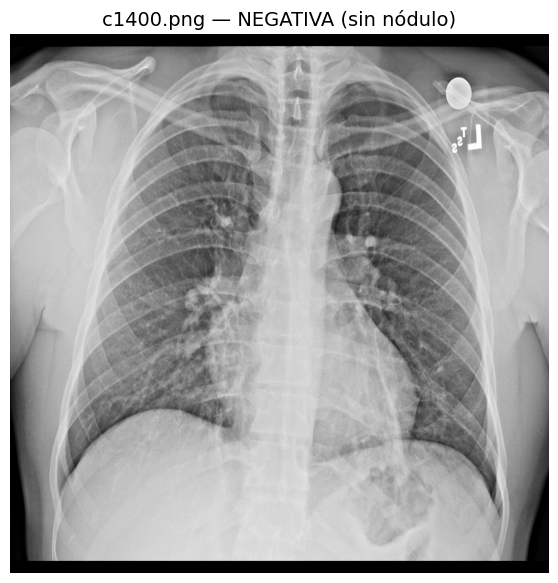

Archivo mostrado: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/c1400.png


In [67]:
show_from_dataset(train_dataset, 1500)

### Obtenció automàtica de canals d’entrada
Funció auxiliar per inferir el nombre de canals d’entrada (`in_channels`) d’un bloc convolucional, suportant diferents estructures com `Conv2d`, `Sequential` o mòduls compostos.


In [68]:
def get_in_channels_from_conv(block):
 
    if isinstance(block, torch.nn.Conv2d):
        return block.in_channels

    if isinstance(block, torch.nn.Sequential):
        return get_in_channels_from_conv(block[0])

    # Conv2dNormActivation
    if hasattr(block, "0") and isinstance(block[0], torch.nn.Conv2d):
        return block[0].in_channels

    raise ValueError(f"No se pudo inferir in_channels desde {type(block)}")


### Congelació de Batch Normalization
Funció auxiliar per posar les capes `BatchNorm2d` en mode *eval* i congelar els seus paràmetres, evitant que s’actualitzin durant l’entrenament.


In [69]:
import torch.nn as nn

def freeze_bn(m):
    if isinstance(m, nn.BatchNorm2d):
        m.eval()
        for p in m.parameters():
            p.requires_grad = False


In [86]:
from torchvision.models.detection import retinanet_resnet50_fpn


### Construcció del model RetinaNet
Funció que inicialitza un model RetinaNet amb backbone ResNet-50 + FPN i el configura per a 2 classes (fons + nòdul).


In [87]:
def build_retinanet():
    model = retinanet_resnet50_fpn(
        weights=None,
        weights_backbone=None,
        num_classes=2
    )
    return model


### Configuració de RetinaNet (anchors + fine-tuning)
Inicialització de RetinaNet preentrenat (COCO), definició d’un `AnchorGenerator` personalitzat, congelació/descongelació selectiva de capes (layer4, FPN i head) i substitució del capçal de classificació per adaptar-lo a 2 classes. També es congelen les BatchNorm i s’inicialitza el bias del classificador amb un prior baix per estabilitzar l’entrenament.


In [72]:
import torchvision
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from torchvision.models.detection.anchor_utils import AnchorGenerator

anchor_generator = AnchorGenerator(
    sizes=((8, 16, 32),
           (16, 32, 64),
           (32, 64, 128),
           (64, 128, 256),
           (128, 256, 512)),
    aspect_ratios=((0.5, 1.0, 2.0),) * 5
)

model = torchvision.models.detection.retinanet_resnet50_fpn(
    weights=torchvision.models.detection.RetinaNet_ResNet50_FPN_Weights.COCO_V1,
    anchor_generator=anchor_generator
)

# Congelar todo
for p in model.parameters():
    p.requires_grad = False

# Descongelar layer4
for name, param in model.backbone.body.named_parameters():
    if name.startswith("layer4"):
        param.requires_grad = True

# Descongelar FPN
for p in model.backbone.fpn.parameters():
    p.requires_grad = True

# Descongelar head
for p in model.head.parameters():
    p.requires_grad = True

# Reemplazar classification head
num_anchors = model.head.classification_head.num_anchors
conv_block  = model.head.classification_head.conv
in_channels = get_in_channels_from_conv(conv_block)

model.head.classification_head = RetinaNetClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=2
)

# Enviar TODO a GPU
model.to(device)
model.apply(freeze_bn)


prior = 0.01
bias = -torch.log(torch.tensor((1 - prior) / prior, device=device))

model.head.classification_head.cls_logits.bias.data.fill_(bias)



tensor([-4.5951, -4.5951, -4.5951, -4.5951, -4.5951, -4.5951, -4.5951, -4.5951,
        -4.5951, -4.5951, -4.5951, -4.5951, -4.5951, -4.5951, -4.5951, -4.5951,
        -4.5951, -4.5951], device='cuda:0')

In [73]:
from tqdm import tqdm
import torch

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0

    loop = tqdm(loader, desc="Entrenando", leave=True)

    for images, targets in loop:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Calcular pérdidas
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    return total_loss / len(loader)


### Entrenament d’una època (RetinaNet)
Funció que executa una època d’entrenament del model RetinaNet, calcula la pèrdua total i actualitza els pesos amb l’optimitzador.


In [74]:
def evaluate_one_epoch(model, loader, device):
    model.train()   
    total_loss = 0.0

    loop = tqdm(loader, desc="Validando", leave=True)

    with torch.no_grad():
        for images, targets in loop:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())

            total_loss += loss.item()
            loop.set_postfix(val_loss=loss.item())

    return total_loss / len(loader)


### Entrenament d’una època
Funció que entrena el model durant una època, calcula la pèrdua total i actualitza els pesos mostrant el progrés amb `tqdm`.


In [75]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0

    loop = tqdm(loader, desc="Entrenando", leave=True)

    for images, targets in loop:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        loop.set_postfix(loss=loss.item())

    return total_loss / len(loader)

### Early stopping
Classe per aturar l’entrenament automàticament quan la pèrdua de validació no millora després d’un nombre d’èpoques determinat.


In [76]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return False

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True

        return False


### Comprovació de *data leakage*
Verificació que no hi ha imatges compartides entre els conjunts d’entrenament i validació (intersecció = 0).


In [77]:
train_set = set(train_df["file_path"].unique())
val_set   = set(val_df["file_path"].unique())
print("Intersección:", len(train_set.intersection(val_set)))

Intersección: 0


In [78]:
# 1) Sin leakage
print(len(set(train_df.file_path) & set(val_df.file_path)))  # 0

# 2) BN congelado
for m in model.modules():
    if isinstance(m, torch.nn.BatchNorm2d):
        assert not m.training

# 3) Solo algunos parámetros entrenables
sum(p.requires_grad for p in model.parameters())


0


46

### Entrenament complet amb *scheduler* i guardat de models
Bucle principal d’entrenament i validació amb optimitzador AdamW, planificador de taxa d’aprenentatge (*MultiStepLR*), guardat de checkpoints i selecció del millor model segons la pèrdua de validació, amb suport d’early stopping.


In [79]:
import torch.optim as optim
import os
from datetime import datetime

MODEL_DIR = "/content/drive/MyDrive/ML/DATASETS/NODE21/models"


# Timestamp único por ejecución
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"Run ID: {RUN_ID}")


optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5,
    weight_decay=1e-4
)


scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[2, 4],
    gamma=0.1
)

num_epochs = 20
early_stopper = EarlyStopping(patience=20, min_delta=0.0001)

best_val_loss = float("inf")

for epoch in range(num_epochs):
    print(f"\n===== Epoch {epoch+1}/{num_epochs} =====")

    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss   = evaluate_one_epoch(model, val_loader, device)

    print(f"Epoch {epoch+1}:")
    print(f"  → Train Loss: {train_loss:.4f}")
    print(f"  → Val Loss:   {val_loss:.4f}")

    # Guardar checkpoint por epoch (opcional pero recomendable)
    checkpoint_path = (
        f"{MODEL_DIR}/checkpoint_retinanet_epoch_{epoch+1:02d}_{RUN_ID}.pth"
    )
    torch.save(model.state_dict(), checkpoint_path)

    # Guardar mejor modelo de ESTA ejecución
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        best_model_path = (
            f"{MODEL_DIR}/best_retinanet_frcnn_node21_{RUN_ID}.pth"
        )
        torch.save(model.state_dict(), best_model_path)

        print("Guardado nuevo MEJOR MODELO de la ejecución")

    scheduler.step()

    # Early stopping
    if early_stopper.step(val_loss):
        print(f"\n Early stopping activado en Epoch {epoch+1}")
        print(f"Mejor epoch = {epoch+1 - early_stopper.patience}")
        break


Run ID: 20260102_110739

===== Epoch 1/20 =====


Validando: 100%|██████████| 813/813 [02:10<00:00,  6.24it/s, val_loss=0.637]


Epoch 1:
  → Train Loss: 0.6661
  → Val Loss:   0.5504
Guardado nuevo MEJOR MODELO de la ejecución

===== Epoch 2/20 =====


Validando: 100%|██████████| 813/813 [02:10<00:00,  6.25it/s, val_loss=0.471]


Epoch 2:
  → Train Loss: 0.4862
  → Val Loss:   0.5025
Guardado nuevo MEJOR MODELO de la ejecución

===== Epoch 3/20 =====


...

Epoch 5:
  → Train Loss: 0.2410
  → Val Loss:   0.4720

===== Epoch 6/20 =====


Validando: 100%|██████████| 813/813 [02:10<00:00,  6.25it/s, val_loss=0.293]


Epoch 6:
  → Train Loss: 0.2351
  → Val Loss:   0.4717

===== Epoch 7/20 =====


Entrenando:  91%|█████████ | 2982/3275 [14:23<01:24,  3.45it/s, loss=0.363]Exception in thread Thread-47 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 541, in rebuild_storage_fd
    fd = df.detach()

KeyboardInterrupt: 

### Càrrega i visualització de prediccions (RetinaNet)
Aquesta cel·la carrega el millor checkpoint entrenat de RetinaNet, posa el model en mode d’avaluació i defineix una funció per visualitzar les deteccions sobre una imatge del dataset, mostrant el *ground truth* i les prediccions filtrades per un llindar de confiança.


In [ ]:
MODEL_DIR = "/content/drive/MyDrive/ML/DATASETS/NODE21/models"
MODEL_PATH = f"{MODEL_DIR}/best_retinanet_frcnn_node21_YYYYMMDD_HHMMSS.pth"

# Cargar pesos
state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)

model.to(device)
model.eval()

print("Modelo RetinaNet cargado correctamente.")
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

def show_prediction(model, dataset, idx, score_thresh=0.3):
    model.eval()

    img, target = dataset[idx]
    img_np = img[0].cpu().numpy()   # canal 0
    image = img.to(device)

    with torch.no_grad():
        outputs = model([image])

    pred = outputs[0]
    pred_boxes  = pred["boxes"].cpu().numpy()
    pred_scores = pred["scores"].cpu().numpy()

    # Filtrar por score
    keep = pred_scores >= score_thresh
    pred_boxes  = pred_boxes[keep]
    pred_scores = pred_scores[keep]

    # ------------------------
    # Visualización
    # ------------------------
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(img_np, cmap="gray")

    # GT (opcional)
    for (x1, y1, x2, y2) in target["boxes"].cpu().numpy():
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor="lime", facecolor="none"
        )
        ax.add_patch(rect)

    # Predicciones RetinaNet
    for (x1, y1, x2, y2), s in zip(pred_boxes, pred_scores):
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor="red", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1, f"{s:.2f}", color="yellow", fontsize=10)

    ax.set_title(f"GT=verde • Pred=rojo • idx={idx}")
    ax.axis("off")
    plt.show()
